Cleaning data...
Data cleaning complete.
------------------------------
Full X/y shape: (7038,), (7038, 14)
------------------------------
Training data shape: (5630, 14),(5630,)
Testing data shape: (1408, 14),(1408,)
------------------------------
Scaling data...
Data scaling complete.
------------------------------
Applying Recursive Feature Elimination (RFE)...
RFE selected 8 features:
['AltitudeVariation', 'VehicleSpeedAverage', 'VehicleSpeedVariation', 'ManifoldAbsolutePressure', 'EngineRPM', 'FuelConsumptionAverage', 'VehicleSpeedInstantaneous', 'MassAirFlow']
New training data shape after RFE: (5630, 8)
New testing data shape after RFE: (1408, 8)
------------------------------
Applying SMOTE to training data...
Original selected training shape: (5630, 8), (5630,)
SMOTEd training data shape: (9200, 8), (9200,)
Class distribution after SMOTE:
drivingStyleNumeric
0    50.0
1    50.0
Name: proportion, dtype: float64
------------------------------
--- Starting Hyperparameter Tuning (

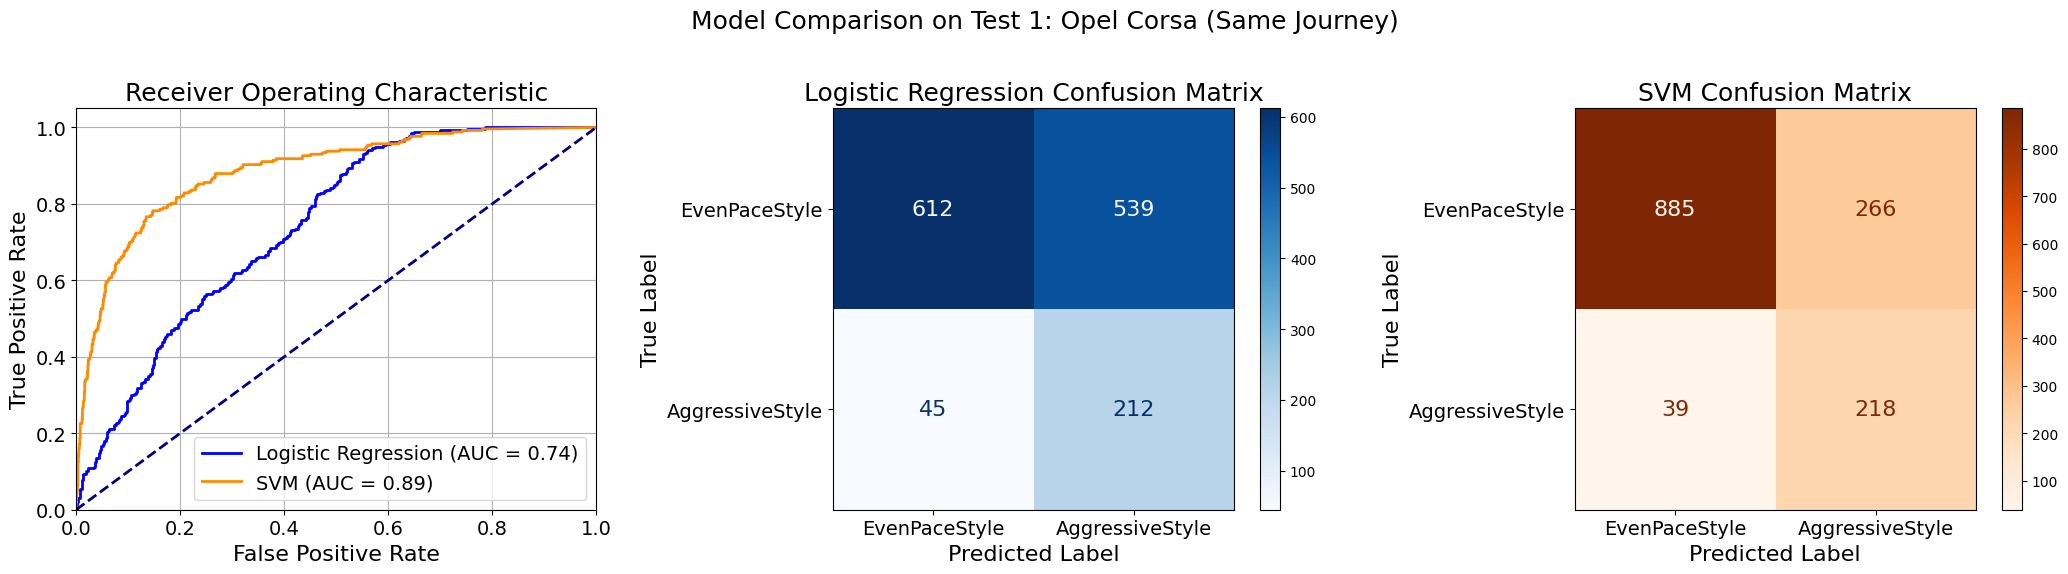


--- Evaluating models on Test Data 2 (Opel Corsa 2) ---
Testing2 data shape: (4092, 8),(4092,)
--- Comparison on Test 2: Opel Corsa (Different Journey) ---

--- Logistic Regression Metrics ---
Accuracy:     0.6288
AUC:          0.7239
Precision (Aggressive): 0.2948
Recall (Aggressive):    0.6421
F1-Score (Aggressive):  0.4041
Specificity (EvenPace): 0.6255
FPR (EvenPace):         0.3745

Classification Report (Full):
                 precision    recall  f1-score   support

  EvenPaceStyle       0.88      0.63      0.73      3290
AggressiveStyle       0.29      0.64      0.40       802

       accuracy                           0.63      4092
      macro avg       0.59      0.63      0.57      4092
   weighted avg       0.76      0.63      0.67      4092


--- SVM Metrics ---
Accuracy:     0.6997
AUC:          0.6838
Precision (Aggressive): 0.3257
Recall (Aggressive):    0.4975
F1-Score (Aggressive):  0.3937
Specificity (EvenPace): 0.7489
FPR (EvenPace):         0.2511

Classification

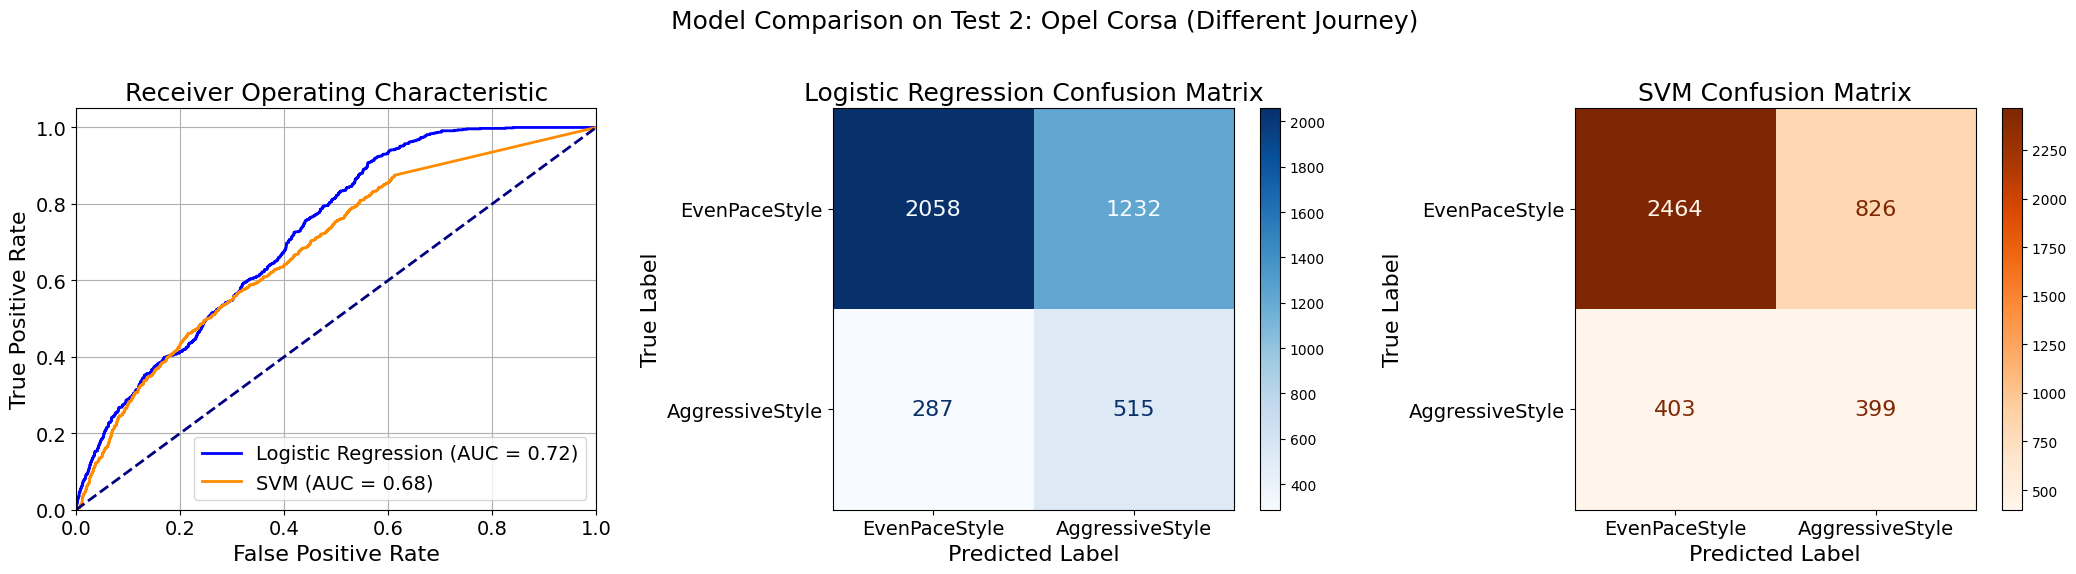

------------------------------

--- Evaluating models on Test Data 3 (Peugeot 207 1) ---
Testing3 data shape: (8192, 8),(8192,)
--- Comparison on Test 3: Peugeot 207 (Journey 1) ---

--- Logistic Regression Metrics ---
Accuracy:     0.6656
AUC:          0.5713
Precision (Aggressive): 0.0648
Recall (Aggressive):    0.3478
F1-Score (Aggressive):  0.1093
Specificity (EvenPace): 0.6856
FPR (EvenPace):         0.3144

Classification Report (Full):
                 precision    recall  f1-score   support

  EvenPaceStyle       0.94      0.69      0.79      7709
AggressiveStyle       0.06      0.35      0.11       483

       accuracy                           0.67      8192
      macro avg       0.50      0.52      0.45      8192
   weighted avg       0.89      0.67      0.75      8192


--- SVM Metrics ---
Accuracy:     0.6669
AUC:          0.6087
Precision (Aggressive): 0.0769
Recall (Aggressive):    0.4224
F1-Score (Aggressive):  0.1301
Specificity (EvenPace): 0.6822
FPR (EvenPace):      

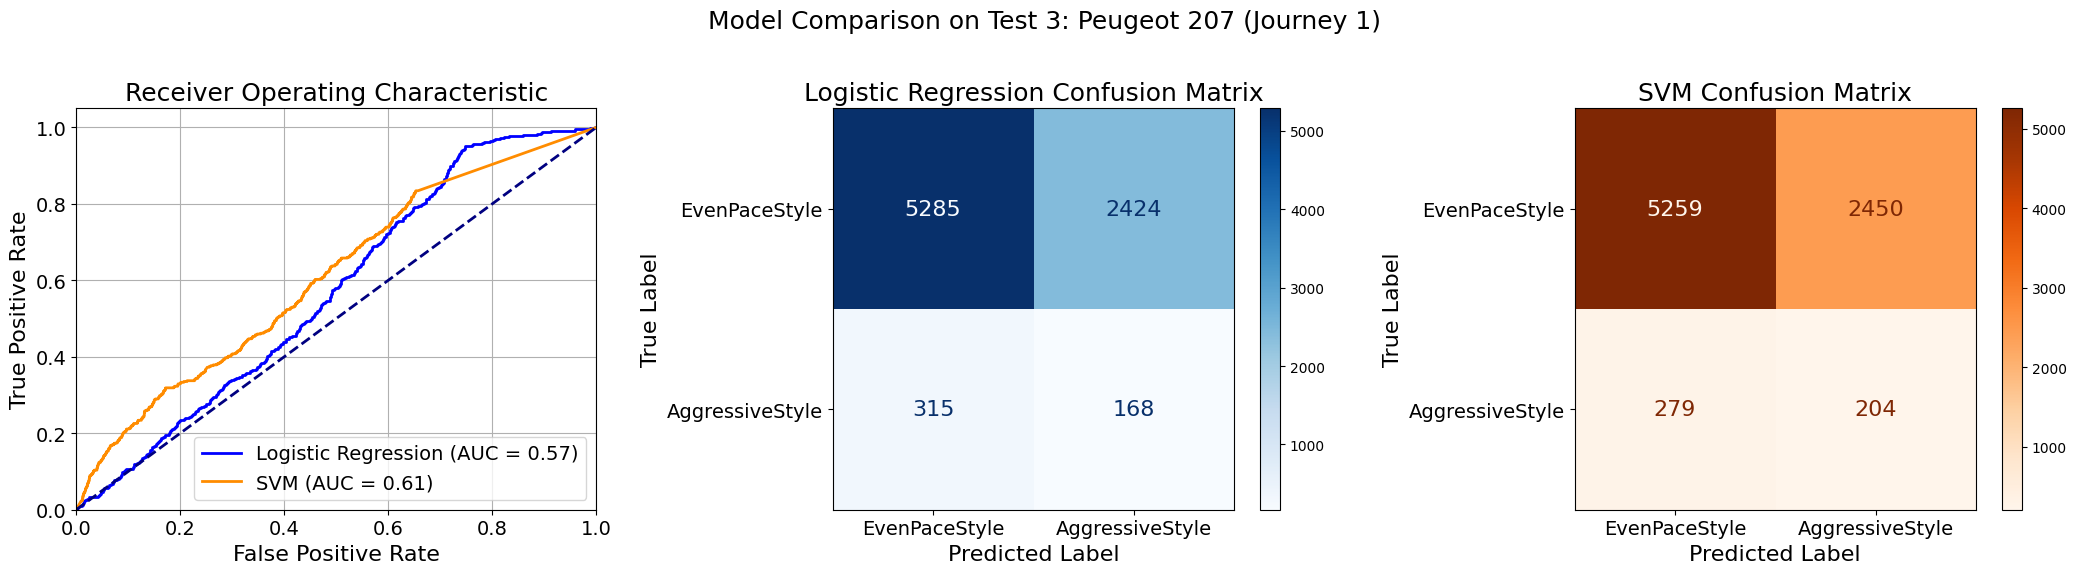

------------------------------

--- Evaluating models on Test Data 4 (Peugeot 207 2) ---
Testing4 data shape: (4440, 8),(4440,)
--- Comparison on Test 4: Peugeot 207 (Journey 2) ---

--- Logistic Regression Metrics ---
Accuracy:     0.6126
AUC:          0.5999
Precision (Aggressive): 0.0557
Recall (Aggressive):    0.5134
F1-Score (Aggressive):  0.1004
Specificity (EvenPace): 0.6170
FPR (EvenPace):         0.3830

Classification Report (Full):
                 precision    recall  f1-score   support

  EvenPaceStyle       0.97      0.62      0.75      4253
AggressiveStyle       0.06      0.51      0.10       187

       accuracy                           0.61      4440
      macro avg       0.51      0.57      0.43      4440
   weighted avg       0.93      0.61      0.73      4440


--- SVM Metrics ---
Accuracy:     0.6498
AUC:          0.6297
Precision (Aggressive): 0.0682
Recall (Aggressive):    0.5775
F1-Score (Aggressive):  0.1220
Specificity (EvenPace): 0.6530
FPR (EvenPace):      

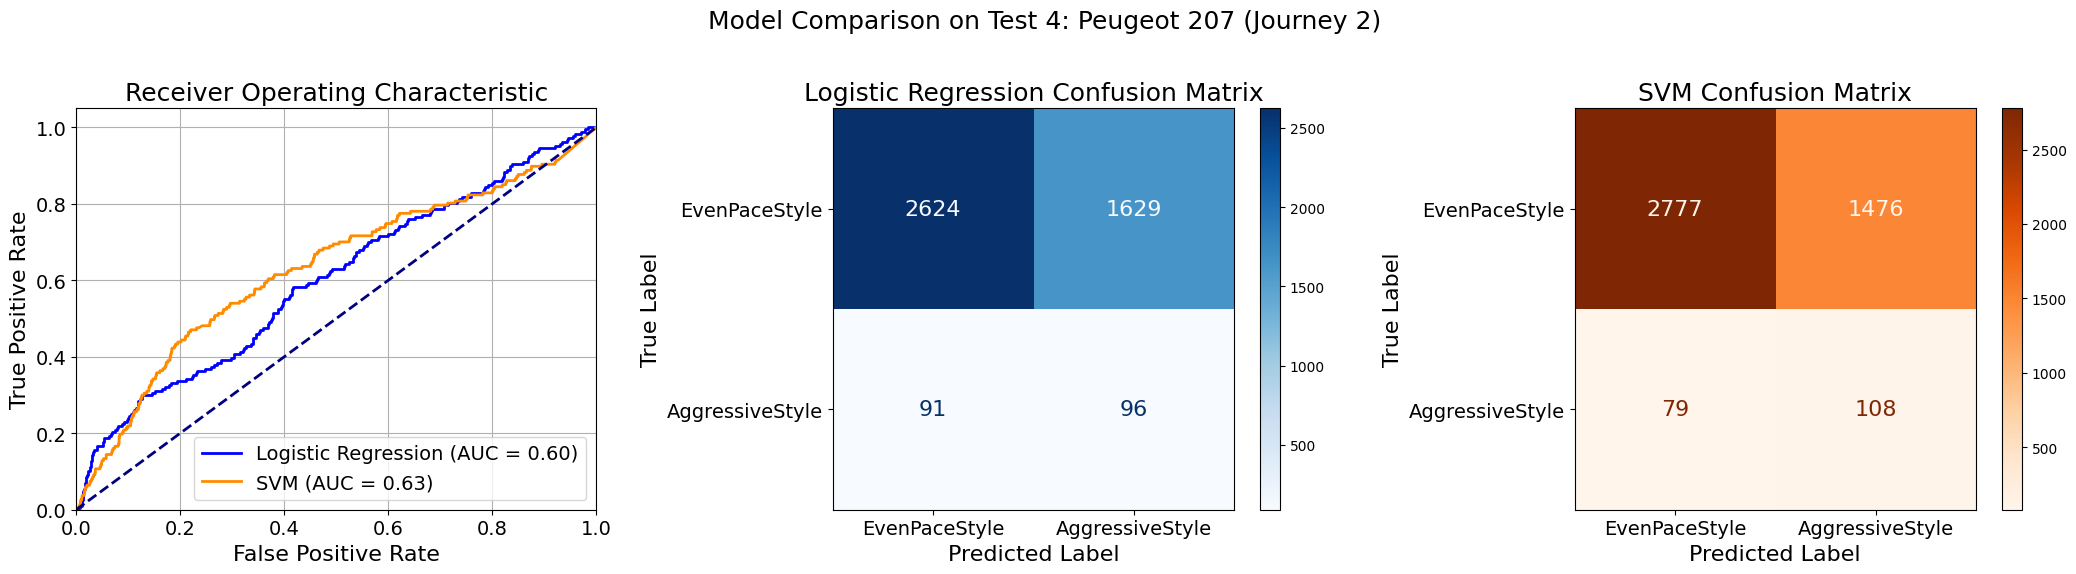

------------------------------

--- Final Results Table ---
| Model               | Test Set                               |   Accuracy |    AUC |   Precision (Aggressive) |   Recall (Aggressive) |   F1-Score (Aggressive) |   Specificity (EvenPace) |   FPR (EvenPace) |
|:--------------------|:---------------------------------------|-----------:|-------:|-------------------------:|----------------------:|------------------------:|-------------------------:|-----------------:|
| Logistic Regression | Test 1: Opel Corsa (Same Journey)      |     0.5852 | 0.7428 |                   0.2823 |                0.8249 |                  0.4206 |                   0.5317 |           0.4683 |
| SVM                 | Test 1: Opel Corsa (Same Journey)      |     0.7834 | 0.8850 |                   0.4504 |                0.8482 |                  0.5884 |                   0.7689 |           0.2311 |
| Logistic Regression | Test 2: Opel Corsa (Different Journey) |     0.6288 | 0.7239 |              

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import RFE  # <-- Added RFE
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score
)
from warnings import filterwarnings
filterwarnings('ignore') # Suppress warnings for cleaner output

# --- 1. Understanding the datasets ---

# Import Opel Corsa 1 Datasets
cor_1_df = pd.read_csv('/content/opel_corsa_01.csv', delimiter=';')
# Import Opel Corsa 2 Datasets
cor_2_df = pd.read_csv('/content/opel_corsa_02.csv', delimiter=';')
# Import Peugeot 207 1 Datasets
peu_1_df = pd.read_csv('/content/peugeot_207_01.csv', delimiter=';')
# Import Peugeot 207 2 Datasets
peu_2_df = pd.read_csv('/content/peugeot_207_02.csv', delimiter=';')

# --- 2. Data Cleaning and Preparation ---

def prep_dataset(df):
    """Changes classes to numeric and drops NA values."""
    style_mapping = {
        'EvenPaceStyle': 0,
        'AggressiveStyle': 1
    }
    df['drivingStyleNumeric'] = df['drivingStyle'].map(style_mapping)
    df = df.dropna()
    return df

print("Cleaning data...")
cor_1_df = prep_dataset(cor_1_df)
cor_2_df = prep_dataset(cor_2_df)
peu_1_df = prep_dataset(peu_1_df)
peu_2_df = prep_dataset(peu_2_df)
print("Data cleaning complete.")
print("-" * 30)


# --- 3. Define All Features ---
# This is the full list of 14 features available
all_features = ['AltitudeVariation',
                'VehicleSpeedAverage',
                'VehicleSpeedVariance',
                'VehicleSpeedVariation',
                'EngineLoad',
                'EngineCoolantTemperature',
                'ManifoldAbsolutePressure', # Added this missing feature
                'EngineRPM',
                'IntakeAirTemperature',
                'VerticalAcceleration',
                'FuelConsumptionAverage',
                'VehicleSpeedInstantaneous',
                'LongitudinalAcceleration',
                'MassAirFlow']

# --- 4. Training Data Setup (Opel Corsa 1) ---
X = cor_1_df[all_features]
y = cor_1_df['drivingStyleNumeric']
print(f"Full X/y shape: {y.shape}, {X.shape}")
print("-" * 30)

# Split the data into training (80%) and testing (20%) sets FIRST
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)
print(f"Training data shape: {X_train1.shape},{y_train1.shape}")
print(f"Testing data shape: {X_test1.shape},{y_test1.shape}")
print("-" * 30)


# --- 5. Scale Data ---
# Scaler is fit ONLY on the training data
print("Scaling data...")
scaler = StandardScaler()
X_train1_scaled = scaler.fit_transform(X_train1)
X_test1_scaled = scaler.transform(X_test1) # Use same scaler for test 1
print("Data scaling complete.")
print("-" * 30)


# --- 6. Feature Selection (Backward Propagation) ---
print("Applying Recursive Feature Elimination (RFE)...")
# We will use RFE, which is a form of backward propagation.
# We need to give it a base model to estimate feature importance.
rfe_estimator = LogisticRegression(solver='liblinear', max_iter=500)

# Initialize RFE to select the 8 best features
rfe = RFE(estimator=rfe_estimator, n_features_to_select=8, step=1)

# Fit RFE on the *scaled training data*
X_train1_selected = rfe.fit_transform(X_train1_scaled, y_train1)

# Get the list of selected features
selected_feature_names = rfe.get_feature_names_out(all_features)
print(f"RFE selected {len(selected_feature_names)} features:")
print(list(selected_feature_names))

# Apply the same feature selection to our hold-out test set
X_test1_selected = rfe.transform(X_test1_scaled)
print(f"New training data shape after RFE: {X_train1_selected.shape}")
print(f"New testing data shape after RFE: {X_test1_selected.shape}")
print("-" * 30)


# --- 7. Apply SMOTE for imbalance ---
print("Applying SMOTE to training data...")
sm = SMOTE(random_state=42)
X_train1_smoted, y_train1_smoted = sm.fit_resample(X_train1_selected, y_train1)
print(f"Original selected training shape: {X_train1_selected.shape}, {y_train1.shape}")
print(f"SMOTEd training data shape: {X_train1_smoted.shape}, {y_train1_smoted.shape}")
print("Class distribution after SMOTE:")
print(pd.Series(y_train1_smoted).value_counts(normalize=True) * 100)
print("-" * 30)


# --- 8. Hyperparameter Tuning ---
print("--- Starting Hyperparameter Tuning (using GridSearchCV) ---")

# --- Logistic Regression Tuning ---
print("Tuning Logistic Regression...")
# Define parameter grid for Logistic Regression
param_grid_logreg = {
    'C': [0.6,1] # C is the inverse of regularization strength (lambda)
}
# Initialize GridSearchCV
# REMOVED class_weight='balanced' because we are using SMOTE
grid_logreg = GridSearchCV(
    LogisticRegression(solver='liblinear', max_iter=1000),
    param_grid_logreg,
    cv=3, # 3-fold cross-validation
    scoring='f1', # Score based on F1
    n_jobs=-1 # Use all available CPU cores
)
# Fit to the scaled, selected, and SMOTEd training data
grid_logreg.fit(X_train1_smoted, y_train1_smoted)
# Get the best model
model_logreg = grid_logreg.best_estimator_
print(f"Best Logistic Regression Params: {grid_logreg.best_params_}")
print(f"Best LR Cross-Validation F1-Score: {grid_logreg.best_score_:.4f}")


# --- SVM Tuning ---
print("\nTuning SVM...")
# Define parameter grid for SVM
param_grid_svm = {
    'C': [5000],
    "gamma": ["scale"],
    'kernel': ['rbf',]
}
# Initialize GridSearchCV
grid_svm = GridSearchCV(
    SVC(random_state=42, probability=True), # REMOVED class_weight, SMOTE handles it
    param_grid_svm,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
# Fit to the scaled, selected, and SMOTEd training data
grid_svm.fit(X_train1_smoted, y_train1_smoted)

model_svm = grid_svm.best_estimator_
print(f"Best SVM Params: {grid_svm.best_params_}")
print(f"Best SVM Cross-Validation F1-Score: {grid_svm.best_score_:.4f}")
print("-" * 30)


# --- 9. Set Classification Thresholds ---
# Default threshold is 0.5
# You can tune these values (e.g., 0.4, 0.35) to find a better
# balance between Precision and Recall for the 'Aggressive' class.
logreg_threshold = 0.45
svm_threshold = 0.25
print(f"Using Thresholds: LogReg={logreg_threshold}, SVM={svm_threshold}")
print("-" * 30)


# --- 10. Helper Function for Comparison ---

def plot_model_comparisons(model1, model2, X_test, y_test, model1_name, model2_name, test_name, threshold1=0.5, threshold2=0.5):
    """
    Compares two models by printing metrics and plotting
    a combined ROC curve and side-by-side confusion matrices.
    Returns a list of dictionaries, each containing metrics for one model.
    """
    print(f"--- Comparison on {test_name} ---")

    display_labels = ['EvenPaceStyle', 'AggressiveStyle']
    all_metrics_for_this_test = [] # To store metrics for both models in this specific test

    # --- Model 1 ---
    try:
        # Get probabilities for class 1
        y_prob1 = model1.predict_proba(X_test)[:, 1]
        # Apply custom threshold to get predictions
        y_pred1 = (y_prob1 >= threshold1).astype(int)

        fpr1, tpr1, _ = roc_curve(y_test, y_prob1)
        roc_auc1 = auc(fpr1, tpr1)
        cm1 = confusion_matrix(y_test, y_pred1)

        # Ensure cm is 2x2, even if one class wasn't predicted
        if cm1.shape == (1, 1):
            if y_test.nunique() == 1: # Only one class in y_test
                if y_test.iloc[0] == 0: cm1 = [[cm1[0][0], 0], [0, 0]] # Only TN
                else: cm1 = [[0, 0], [0, cm1[0][0]]] # Only TP
            else: # Model only predicted one class
                if y_pred1[0] == 0: cm1 = [[cm1[0][0], 0], [cm1[1][0], 0]] # Only predicted 0
                else: cm1 = [[0, cm1[0][0]], [0, cm1[1][0]]] # Only predicted 1

        # Handle potential edge cases where confusion matrix isn't 2x2
        if cm1.shape == (2, 2):
            tn1, fp1, fn1, tp1 = cm1.ravel()
        else:
            # Fallback if confusion matrix is still not right (e.g., only one class in y_test)
            tn1, fp1, fn1, tp1 = 0, 0, 0, 0
            if y_test.nunique() == 1:
                if y_test.iloc[0] == 0: tn1 = len(y_test)
                else: tp1 = len(y_test)
            # This is a simplification; a full solution is more complex
            print(f"Warning: Could not calculate full metrics for {model1_name} on {test_name}")


        # Calculate metrics for the 'AggressiveStyle' (Class 1)
        accuracy1 = accuracy_score(y_test, y_pred1)
        precision1 = tp1 / (tp1 + fp1) if (tp1 + fp1) > 0 else 0
        recall1 = tp1 / (tp1 + fn1) if (tp1 + fn1) > 0 else 0 # Corrected for correctness
        f1_score1 = 2 * (precision1 * recall1) / (precision1 + recall1) if (precision1 + recall1) > 0 else 0
        specificity1 = tn1 / (tn1 + fp1) if (tn1 + fp1) > 0 else 0
        fpr_val1 = fp1 / (tn1 + fp1) if (tn1 + fp1) > 0 else 0

        print(f"\n--- {model1_name} Metrics ---")
        print(f"Accuracy:     {accuracy1:.4f}")
        print(f"AUC:          {roc_auc1:.4f}")
        print(f"Precision (Aggressive): {precision1:.4f}")
        print(f"Recall (Aggressive):    {recall1:.4f}")
        print(f"F1-Score (Aggressive):  {f1_score1:.4f}")
        print(f"Specificity (EvenPace): {specificity1:.4f}")
        print(f"FPR (EvenPace):         {fpr_val1:.4f}")

        print(f"\nClassification Report (Full):\n{classification_report(y_test, y_pred1, target_names=display_labels, zero_division=0)}")

        all_metrics_for_this_test.append({
            'Model': model1_name,
            'Test Set': test_name,
            'Accuracy': accuracy1,
            'AUC': roc_auc1,
            'Precision (Aggressive)': precision1,
            'Recall (Aggressive)': recall1,
            'F1-Score (Aggressive)': f1_score1,
            'Specificity (EvenPace)': specificity1,
            'FPR (EvenPace)': fpr_val1
        })

    except Exception as e:
        print(f"Could not evaluate {model1_name}: {e}")
        fpr1, tpr1, roc_auc1, cm1 = None, None, None, None
        all_metrics_for_this_test.append({
            'Model': model1_name,
            'Test Set': test_name,
            'Error': str(e)
        })

    # --- Model 2 ---
    try:
        # Get probabilities for class 1
        y_prob2 = model2.predict_proba(X_test)[:, 1]
        # Apply custom threshold to get predictions
        y_pred2 = (y_prob2 >= threshold2).astype(int)

        fpr2, tpr2, _ = roc_curve(y_test, y_prob2)
        roc_auc2 = auc(fpr2, tpr2)
        cm2 = confusion_matrix(y_test, y_pred2)

        if cm2.shape == (1, 1):
            if y_test.nunique() == 1:
                if y_test.iloc[0] == 0: cm2 = [[cm2[0][0], 0], [0, 0]]
                else: cm2 = [[0, 0], [0, cm2[0][0]]]
            else:
                if y_pred2[0] == 0: cm2 = [[cm2[0][0], 0], [cm2[1][0], 0]]
                else: cm2 = [[0, cm2[0][0]], [0, cm2[1][0]]]

        if cm2.shape == (2, 2):
            tn2, fp2, fn2, tp2 = cm2.ravel()
        else:
            tn2, fp2, fn2, tp2 = 0, 0, 0, 0
            if y_test.nunique() == 1:
                if y_test.iloc[0] == 0: tn2 = len(y_test)
                else: tp2 = len(y_test)
            print(f"Warning: Could not calculate full metrics for {model2_name} on {test_name}")


        # Calculate metrics for the 'AggressiveStyle' (Class 1)
        accuracy2 = accuracy_score(y_test, y_pred2)
        precision2 = tp2 / (tp2 + fp2) if (tp2 + fp2) > 0 else 0
        recall2 = tp2 / (tp2 + fn2) if (tp2 + fn2) > 0 else 0
        f1_score2 = 2 * (precision2 * recall2) / (precision2 + recall2) if (precision2 + recall2) > 0 else 0
        specificity2 = tn2 / (tn2 + fp2) if (tn2 + fp2) > 0 else 0
        fpr_val2 = fp2 / (tn2 + fp2) if (tn2 + fp2) > 0 else 0

        print(f"\n--- {model2_name} Metrics ---")
        print(f"Accuracy:     {accuracy2:.4f}")
        print(f"AUC:          {roc_auc2:.4f}")
        print(f"Precision (Aggressive): {precision2:.4f}")
        print(f"Recall (Aggressive):    {recall2:.4f}")
        print(f"F1-Score (Aggressive):  {f1_score2:.4f}")
        print(f"Specificity (EvenPace): {specificity2:.4f}")
        print(f"FPR (EvenPace):         {fpr_val2:.4f}")

        print(f"\nClassification Report (Full):\n{classification_report(y_test, y_pred2, target_names=display_labels, zero_division=0)}")

        all_metrics_for_this_test.append({
            'Model': model2_name,
            'Test Set': test_name,
            'Accuracy': accuracy2,
            'AUC': roc_auc2,
            'Precision (Aggressive)': precision2,
            'Recall (Aggressive)': recall2,
            'F1-Score (Aggressive)': f1_score2,
            'Specificity (EvenPace)': specificity2,
            'FPR (EvenPace)': fpr_val2
        })

    except Exception as e:
        print(f"Could not evaluate {model2_name}: {e}")
        fpr2, tpr2, roc_auc2, cm2 = None, None, None, None
        all_metrics_for_this_test.append({
            'Model': model2_name,
            'Test Set': test_name,
            'Error': str(e)
        })

    # --- Plotting ---
    fig, axes = plt.subplots(1, 3, figsize=(21, 6)) # 1 row, 3 columns
    fig.suptitle(f'Model Comparison on {test_name}', fontsize=18)

    # Plot 1: Combined ROC
    if all(v is not None for v in [fpr1, tpr1, roc_auc1]):
        axes[0].plot(fpr1, tpr1, color='blue', lw=2, label=f'{model1_name} (AUC = {roc_auc1:.2f})')
    if all(v is not None for v in [fpr2, tpr2, roc_auc2]):
        axes[0].plot(fpr2, tpr2, color='darkorange', lw=2, label=f'{model2_name} (AUC = {roc_auc2:.2f})')

    axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate', fontsize=16)
    axes[0].set_ylabel('True Positive Rate', fontsize=16)
    axes[0].set_title('Receiver Operating Characteristic', fontsize=18)
    axes[0].legend(loc="lower right", fontsize=14)
    axes[0].grid(True)
    axes[0].tick_params(axis='both', which='major', labelsize=14)

    # Plot 2: Model 1 Confusion Matrix
    if cm1 is not None:
        disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=display_labels)
        disp1.plot(ax=axes[1], cmap=plt.cm.Blues, values_format='d')
        axes[1].set_title(f'{model1_name} Confusion Matrix', fontsize=18)
        axes[1].set_xlabel('Predicted Label', fontsize=16)
        axes[1].set_ylabel('True Label', fontsize=16)
        # Adjust inner number fonts
        for labels in disp1.text_:
            for label in labels:
                label.set_fontsize(16)
    else:
        axes[1].text(0.5, 0.5, f'{model1_name}\nFailed', horizontalalignment='center', verticalalignment='center', fontsize=14)
        axes[1].set_title(f'{model1_name} Confusion Matrix', fontsize=16)

    # Plot 3: Model 2 Confusion Matrix
    if cm2 is not None:
        disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=display_labels)
        disp2.plot(ax=axes[2], cmap=plt.cm.Oranges, values_format='d')
        axes[2].set_title(f'{model2_name} Confusion Matrix', fontsize=18)
        axes[2].set_xlabel('Predicted Label', fontsize=16)
        axes[2].set_ylabel('True Label', fontsize=16)
        # Adjust inner number fonts
        for labels in disp2.text_:
            for label in labels:
                label.set_fontsize(16)
    else:
        axes[2].text(0.5, 0.5, f'{model2_name}\nFailed', horizontalalignment='center', verticalalignment='center', fontsize=14)
        axes[2].set_title(f'{model2_name} Confusion Matrix', fontsize=16)

    # Adjust tick label font size for confusion matrices
    axes[1].tick_params(axis='both', which='major', labelsize=14)
    axes[2].tick_params(axis='both', which='major', labelsize=14)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show() # Make sure to show the plot

    return all_metrics_for_this_test # Return a list of dictionaries

# Initialize all_results before the first call to plot_model_comparisons
all_results = []

# --- 11. Run Test 1 (Hold-out) ---
# X_test1_selected is already prepared from section 6
results_test1 = plot_model_comparisons(
    model_logreg, model_svm, X_test1_selected, y_test1,
    "Logistic Regression", "SVM", "Test 1: Opel Corsa (Same Journey)",
    threshold1=logreg_threshold, threshold2=svm_threshold
)
all_results.extend(results_test1)


# --- 12. Test Data 2 - Same vehicle Different Journey ---
print("\n--- Evaluating models on Test Data 2 (Opel Corsa 2) ---")
X_test2 = cor_2_df[all_features] # Start with ALL features
y_test2 = cor_2_df['drivingStyleNumeric']
X_test2_scaled = scaler.transform(X_test2) # Use the same scaler
X_test2_selected = rfe.transform(X_test2_scaled) # Use the same rfe object
print(f"Testing2 data shape: {X_test2_selected.shape},{y_test2.shape}")

results_test2 = plot_model_comparisons(
    model_logreg, model_svm, X_test2_selected, y_test2,
    "Logistic Regression", "SVM", "Test 2: Opel Corsa (Different Journey)",
    threshold1=logreg_threshold, threshold2=svm_threshold
)
all_results.extend(results_test2)
print("-" * 30)


# --- 13. Test Data 3 - Different vehicle Journey 1 ---
print("\n--- Evaluating models on Test Data 3 (Peugeot 207 1) ---")
X_test3 = peu_1_df[all_features] # Start with ALL features
y_test3 = peu_1_df['drivingStyleNumeric']
X_test3_scaled = scaler.transform(X_test3) # Use the same scaler
X_test3_selected = rfe.transform(X_test3_scaled) # Use the same rfe object
print(f"Testing3 data shape: {X_test3_selected.shape},{y_test3.shape}")

results_test3 = plot_model_comparisons(
    model_logreg, model_svm, X_test3_selected, y_test3,
    "Logistic Regression", "SVM", "Test 3: Peugeot 207 (Journey 1)",
    threshold1=logreg_threshold, threshold2=svm_threshold
)
all_results.extend(results_test3)
print("-" * 30)


# --- 14. Test Data 4 - Different vehicle Journey 2 ---
print("\n--- Evaluating models on Test Data 4 (Peugeot 207 2) ---")
X_test4 = peu_2_df[all_features] # Start with ALL features
y_test4 = peu_2_df['drivingStyleNumeric']
X_test4_scaled = scaler.transform(X_test4) # Use the same scaler
X_test4_selected = rfe.transform(X_test4_scaled) # Use the same rfe object
print(f"Testing4 data shape: {X_test4_selected.shape},{y_test4.shape}")

results_test4 = plot_model_comparisons(
    model_logreg, model_svm, X_test4_selected, y_test4,
    "Logistic Regression", "SVM", "Test 4: Peugeot 207 (Journey 2)",
    threshold1=logreg_threshold, threshold2=svm_threshold
)
all_results.extend(results_test4)
print("-" * 30)

# --- 15. Generate Final Results Table ---
print("\n--- Final Results Table ---")
final_results_df = pd.DataFrame(all_results)
# Format the output for better readability
pd.set_option('display.precision', 4)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(final_results_df.to_markdown(index=False, floatfmt=".4f"))

# Save the table to a markdown file
final_results_df.to_markdown("model_results_table_generated.md", index=False, floatfmt=".4f")
print("\nResults table saved to 'model_results_table_generated.md'")